In [261]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 22.8 MB/s eta 0:00:01
     ----------------------------------- --- 11.5/12.8 MB 40.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 38.7 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [299]:
import wordcloud

In [262]:
from sklearn.feature_extraction.text import CountVectorizer
import glob
import pandas as pd
import nltk
import numpy as np
from nltk import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag

In [263]:
# modeli za ustrezno obdelavo stavkov, besed, ločil....
nltk.download('punkt')     # stavki, besede
nltk.download('wordnet') #lemmatizacija
nltk.download('averaged_perceptron_tagger') #POS tagganje
nltk.download('omw-1.4') 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [264]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [265]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [266]:
# tokenization and lemmatization 
lemmatizer= WordNetLemmatizer()

In [267]:
# pokupčkamo besede s podobnim korenom, pomenom skupaj
# run, runs, running -> run
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('RB'):
        return wordnet.ADV
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    else:
        return wordnet.NOUN

In [268]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [269]:
def tokenize_lematize(tekst):
    # Procesiramo tekst s spaCy modelom
    doc = nlp(tekst)
    
    izbrane_besede = []
    
    # Definiramo entitete, ki jih želimo odstraniti (osebe, kraji, jeziki, narodi)
    odstrani_entitete = {'PERSON', 'GPE', 'LOC', 'NORP', 'FAC', 'ORG'}
    
    # Ustvarimo množico besed, ki so del prepoznanih entitet (imen)
    imena_v_tekstu = {ent.text.lower() for ent in doc.ents if ent.label_ in odstrani_entitete}

    for token in doc:
        # 1. Preverimo če je beseda ime (NER)
        if token.text.lower() in imena_v_tekstu:
            continue
            
        # 2. Preverimo če je beseda samostalnik, glagol ali pridevnik (POS)
        # spaCy uporablja oznake: NOUN, VERB, ADJ
        if token.pos_ in ['NOUN', 'VERB', 'ADJ']:
            beseda = token.lemma_.lower()
            
            # 3. Dodatni filtri: samo črke in dolžina nad 2 znaka
            if beseda.isalpha() and len(beseda) > 2:
                izbrane_besede.append(beseda)
                
    return izbrane_besede

In [270]:
from sklearn.feature_extraction import text

In [289]:
base_vectorizer = CountVectorizer(stop_words='english')
base_stopwords = base_vectorizer.get_stop_words()


custom_words = {
    'book', 'novel', 'story', 'reader', 'edition', 'classic', 'introduction',
    'publish', 'note', 'cover', 'series', 'time', 'year', 'new', 'make', 'tell',
    'begin', 'just', 'work', 'face', 'place', 'mean', 'text', 'author', 'original', 
    'u', 'seller', 'masterpiece', 'literature', 'best', 'read', 'man', 'men', 
    'woman', 'life', 'fiction', 'tale', 'character', 'page', 'write', 'writer',
    'chapter', 'volume', 'collection', 'everything', 'day', 'world', 'come', 'series',
    'know', 'want', 'come'
}


all_stopwords = list(base_stopwords.union(custom_words))

In [290]:
# CountVectorizer odstrani 'stopwords' in ustvari nenegativno matriko, na (i, j)-tem mestu
# imamo pojavitev besede i v j-tem dokumentu (glej zapiske na tablici)


# vzamemo 49/50 knjig, eno bomo potem poskusali uvrstiti med žanre
filepaths = glob.glob(r'C:\Users\mokro\Desktop\diploma\dipl_data\knjige_opisi\*.txt')
# min_df=2, max_df=0.9 odstranita redke in pogoste besede, to uniči celoten rezultat
vectorizer= CountVectorizer(stop_words= all_stopwords, #custom_stopwords, 
                            tokenizer= tokenize_lematize,
                            input = 'filename', 
                            encoding='latin-1', 
                            min_df=2, 
                            max_df=0.8)

In [291]:
X = vectorizer.fit_transform(filepaths) 


c:\Users\mokro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [292]:
words = vectorizer.get_feature_names_out()
freq = np.asarray(X.sum(axis=0)).flatten()

top_words = [words[i] for i in freq.argsort()[-50:]]
print(top_words)

['adventure', 'win', 'old', 'modern', 'hobbit', 'lose', 'beautiful', 'tragic', 'century', 'evil', 'eye', 'rule', 'freedom', 'consequence', 'terrible', 'secret', 'home', 'murder', 'learn', 'remain', 'father', 'game', 'leave', 'war', 'country', 'set', 'wizard', 'alternate', 'include', 'grow', 'friendship', 'live', 'school', 'voldemort', 'friend', 'good', 'ring', 'boy', 'student', 'force', 'great', 'power', 'turn', 'young', 'age', 'family', 'death', 'dark', 'hogwart', 'love']


In [293]:
print(X)

# malo lepše, prikaz
dense_matrix = X.toarray()
print(dense_matrix)

#še lepše
feature_names = vectorizer.get_feature_names_out()
df = pd.DataFrame(dense_matrix, columns=feature_names)
print(df.head())

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1241 stored elements and shape (49, 423)>
  Coords	Values
  (0, 298)	1
  (0, 406)	2
  (0, 135)	2
  (0, 38)	2
  (0, 408)	1
  (0, 370)	1
  (0, 270)	1
  (0, 420)	1
  (0, 105)	1
  (0, 97)	1
  (0, 245)	1
  (0, 288)	1
  (0, 219)	1
  (0, 8)	1
  (0, 316)	1
  (0, 278)	1
  (0, 185)	1
  (0, 183)	1
  (0, 155)	1
  (0, 305)	1
  (0, 24)	1
  (0, 72)	1
  (0, 88)	1
  (0, 382)	1
  (0, 131)	1
  :	:
  (48, 137)	1
  (48, 117)	1
  (48, 181)	1
  (48, 325)	1
  (48, 340)	1
  (48, 273)	2
  (48, 247)	1
  (48, 312)	1
  (48, 259)	1
  (48, 84)	1
  (48, 184)	1
  (48, 83)	1
  (48, 165)	1
  (48, 266)	1
  (48, 28)	2
  (48, 173)	1
  (48, 98)	1
  (48, 63)	1
  (48, 398)	1
  (48, 149)	1
  (48, 307)	1
  (48, 94)	1
  (48, 333)	1
  (48, 26)	1
  (48, 334)	1
[[0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 ...
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
   acclaim  achieve  achievement  act  action  adapt  adult  adventure  \
0        0        0  

In [294]:
def nmf(X, k, max_iter=500, tol=1e-4, random_state=42):
    """
    Nenegativna matrična faktorizacija, ki uporablja pravila za posodobitev elementov na podlagi množenja.

    Parametri:
    -----------
    X : ndarray (m x n)
        Nenegativna matrika
    k : int
        Število komponent (teme/ žanri)
    max_iter : int
        Maksimalno število iteracij
    tol : float
        Toleranca konvergence (izračunano s pomočjo reconstruction error)
    random_state : int
        

    Vrne:
    --------
    W : ndarray (m x k)
    H : ndarray (k x n)
    errors : list
        Reconstruction error za vsako iteracijo
    """
    
    np.random.seed(random_state)
    
    m, n = X.shape
    
    #zacnemo z nakljucnimi nenegativnimi vrednostmi
    W = np.random.rand(m, k)
    H = np.random.rand(k, n)
    
    eps = 1e-9
    errors = []
    
    for i in range(max_iter):
        
        # posodabljanje H
        H *= (W.T @ X) / (W.T @ W @ H + eps) # + eps, da ne delimo z 0
        # posodabljanje W
        W *= (X @ H.T) / (W @ (H @ H.T) + eps)
        
        # reconstruction error
        error = np.linalg.norm(X - W @ H, 'fro')
        errors.append(error)
        
        # konvergenca
        if i > 0 and abs(errors[-2] - error) < tol:
            break
    return W, H, errors

In [297]:
# test na 'slabem' datasetu

W, H, errors = nmf(X, 4)
print(errors)
#print(W)
#print(H)

[np.float64(38.197664500782125), np.float64(37.30253086569111), np.float64(36.46294647683444), np.float64(35.87828223055481), np.float64(35.55859883505073), np.float64(35.355662017360146), np.float64(35.21657535857161), np.float64(35.124506264561575), np.float64(35.066458255525035), np.float64(35.030023316521884), np.float64(35.00557358983417), np.float64(34.98728210441496), np.float64(34.97209993941735), np.float64(34.958710570545236), np.float64(34.94637953935607), np.float64(34.93455647385766), np.float64(34.92312360047615), np.float64(34.91209150637901), np.float64(34.900849285302165), np.float64(34.88936405703507), np.float64(34.87698748476662), np.float64(34.86467015896865), np.float64(34.85295921626304), np.float64(34.842316573171715), np.float64(34.833285644633854), np.float64(34.82632859340448), np.float64(34.82134344804635), np.float64(34.81806492298198), np.float64(34.81567505663174), np.float64(34.8137626445894), np.float64(34.81206429091243), np.float64(34.80994089307855),

In [278]:
""" # iskanje najbolj ugodne kombinacije min_df in max_df

min_dfs = [2, 3, 4, 5]

results = []

for min_df in min_dfs:
        vectorizer= CountVectorizer(stop_words= 'english',  
                            tokenizer= tokenize_lematize,
                            input = 'filename', 
                            encoding='latin-1', 
                            min_df=min_df)
        X = vectorizer.fit_transform(filepaths)

        W, H, errors = nmf(X, 4)
        results.append({
            "min_df": min_df,
            "error": errors[-1],
            "n_features": X.shape[1]
            
        })
        feature_names = vectorizer.get_feature_names_out()
        for topic_idx, topic in enumerate(H):
            top_words = [feature_names[i] for i in topic.argsort()[-15:]]
            print(f"Tema {topic_idx+1}: {' '.join(top_words)}")
            
for r in results:
    print(r) """
       

' # iskanje najbolj ugodne kombinacije min_df in max_df\n\nmin_dfs = [2, 3, 4, 5]\n\nresults = []\n\nfor min_df in min_dfs:\n        vectorizer= CountVectorizer(stop_words= \'english\',  \n                            tokenizer= tokenize_lematize,\n                            input = \'filename\', \n                            encoding=\'latin-1\', \n                            min_df=min_df)\n        X = vectorizer.fit_transform(filepaths)\n\n        W, H, errors = nmf(X, 4)\n        results.append({\n            "min_df": min_df,\n            "error": errors[-1],\n            "n_features": X.shape[1]\n\n        })\n        feature_names = vectorizer.get_feature_names_out()\n        for topic_idx, topic in enumerate(H):\n            top_words = [feature_names[i] for i in topic.argsort()[-15:]]\n            print(f"Tema {topic_idx+1}: {\' \'.join(top_words)}")\n\nfor r in results:\n    print(r) '

In [298]:
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(H):
    top_words = [feature_names[i] for i in topic.argsort()[-15:]]
    print(f"Tema {topic_idx+1}: {' '.join(top_words)}")

Tema 1: forge fall perilous crack young journey remain hobbit rule power dark middle baggin earth ring
Tema 2: unlikely grow act way power win hunger district country father game death friendship family love
Tema 3: beautiful war terrible great boy loneliness force turn young escape sense age good language teenage
Tema 4: strong wizardry witchcraft good learn friend evil school student death wizarde dark voldemort wizard hogwart


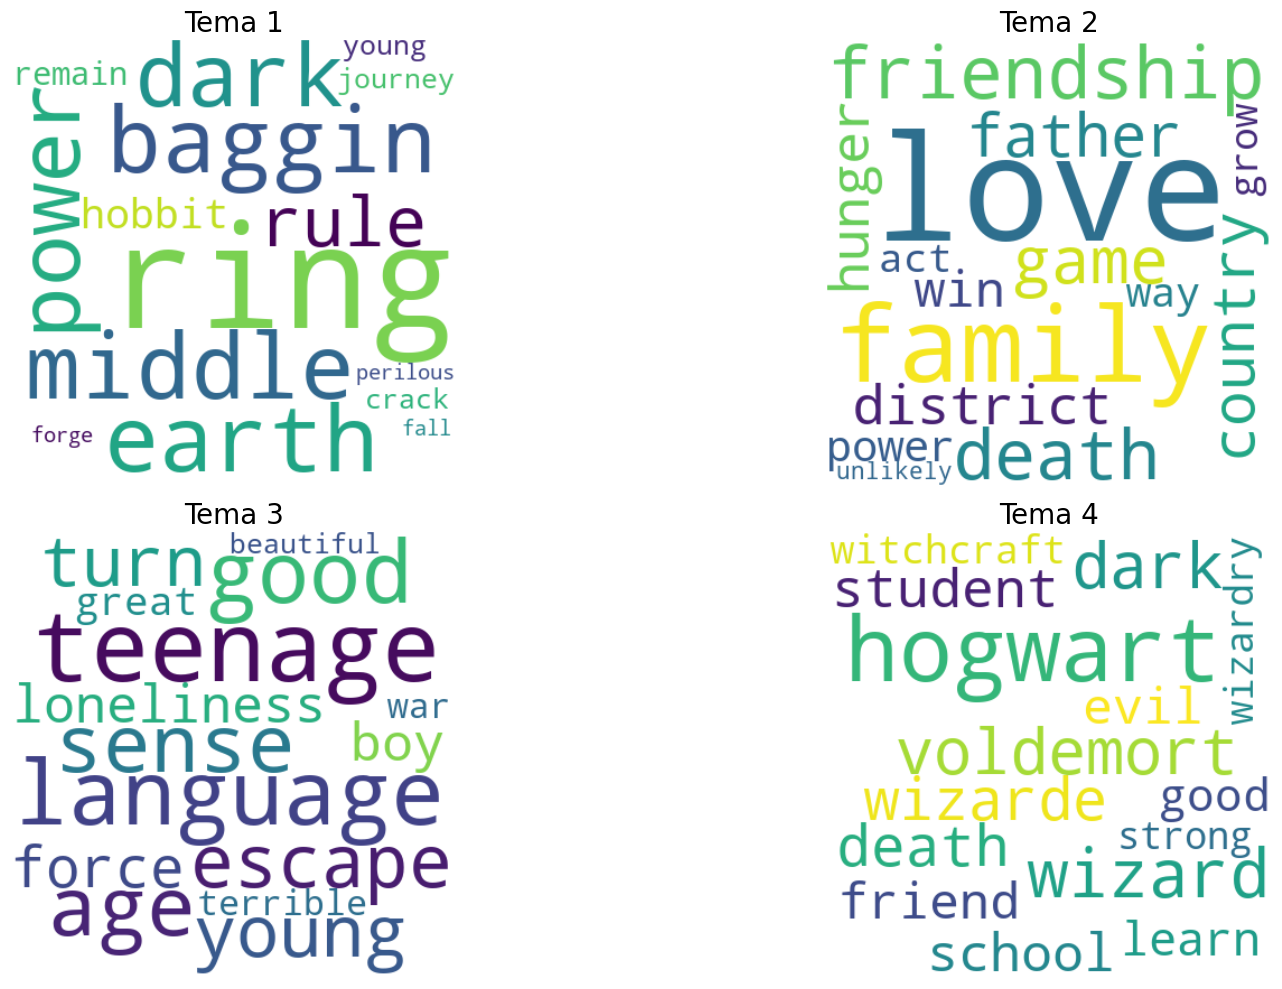

In [301]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def prikazi_wordclouds(H, feature_names, n_top_words=15):
    n_topics = H.shape[0]
    
    
    plt.figure(figsize=(20, 10))
    
    for topic_idx, topic in enumerate(H):
        # slovar {beseda: utež} za WordCloud
        # top n besed za vsako temo
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        topic_words = {feature_names[i]: topic[i] for i in top_features_ind}
        
        
        wc = WordCloud(width=400, height=400, background_color='white', 
                       colormap='viridis', max_words=n_top_words)
        wc.generate_from_frequencies(topic_words)
    
        plt.subplot(2, 2, topic_idx + 1)
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Tema {topic_idx + 1}", fontsize=20)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

feature_names = vectorizer.get_feature_names_out()
prikazi_wordclouds(H, feature_names)